In [1]:
import os
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from scipy.stats import wasserstein_distance
from scipy.stats import chi2 as chi2_stat
import yaml
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import torch
import pandas as pd
from sklearn.utils import resample
helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

os.environ["CUDA_VISIBLE_DEVICES"] = ""

# ==============================================================================
# 1. PLOTTING FUNCTION
# ==============================================================================
def plot_closure(region_name: str, df_mc: pl.DataFrame, df_gen: pl.DataFrame, df_data: pl.DataFrame, feature: str, force_log: bool = False):
    """
    Combined HEP closure plot comparing Target Data vs:
    1. Nominal MC
    2. ML Reweighted MC
    3. Generated Synthetic Data
    
    Styled to match ATLAS-like data/MC comparisons with stat bands and dynamic bounds.
    """
    
    # Thesis/Publication styling settings
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 12,
        'lines.linewidth': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'axes.formatter.use_mathtext': True,
        'axes.linewidth': 1.2,
        'hatch.linewidth': 0.5
    })
    
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }
    
    log_variables = ['ht', 'met_recalc_pt', 'met', 'mjj']
    use_log = force_log or any(log_var in feature.lower() for log_var in log_variables)
    
    # Extract arrays
    data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
    mc_arr = df_mc.get_column(feature).drop_nulls().to_numpy()
    gen_arr = df_gen.get_column(feature).drop_nulls().to_numpy()
    
    if len(data_arr) == 0:
        print(f"Skipping {feature} - No valid target data.")
        return
        
    # Extract Weights
    data_weight_col = "final_weight" if "final_weight" in df_data.columns else ("raw_weights" if "raw_weights" in df_data.columns else None)
    data_weights = df_data.get_column(data_weight_col).to_numpy() if data_weight_col else np.ones_like(data_arr)
    
    mc_weight_col = "final_weight" 
    raw_weights_mc = df_mc.get_column(mc_weight_col).to_numpy() if mc_weight_col else np.ones_like(mc_arr)
    ml_weights_mc = df_mc.get_column("ml_extrapolation_weight").to_numpy() if "ml_extrapolation_weight" in df_mc.columns else np.ones_like(mc_arr)
    reweighted_mc_weights = raw_weights_mc * ml_weights_mc
    
    gen_weights = df_gen.get_column("weight").to_numpy() if "weight" in df_gen.columns else np.ones_like(gen_arr)
    
    # Setup Figure
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
    
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    # Dynamic binning spanning all distributions
    combined_arr = np.concatenate([data_arr, mc_arr, gen_arr])
    bins = np.histogram_bin_edges(combined_arr, bins=15)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = np.diff(bins)

    # --- MAIN PANEL ---
    # Nominal MC
    counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights_mc)
    sumw2_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights_mc**2)
    ax_main.hist(mc_arr, bins=bins, weights=raw_weights_mc, histtype='step', 
                 color='#e31a1c', linewidth=2, linestyle='--', label='Nominal MC')
                 
    mc_err = np.sqrt(sumw2_mc_raw)
    ax_main.bar(bin_centers, 2 * mc_err, bottom=counts_mc_raw - mc_err, width=bin_widths,
                color='none', edgecolor='gray', hatch='////', linewidth=0,
                alpha=0.5, zorder=5, label='Stat. Unc.')
    
    # ML Reweighted MC
    counts_mc_ml, _ = np.histogram(mc_arr, bins=bins, weights=reweighted_mc_weights)
    sumw2_mc_ml, _ = np.histogram(mc_arr, bins=bins, weights=reweighted_mc_weights**2)
    ax_main.hist(mc_arr, bins=bins, weights=reweighted_mc_weights, histtype='stepfilled', 
                 color='#1f78b4', alpha=0.3, edgecolor='#1f78b4', label='Reweighted MC')
                 
    # Generated Model
    counts_gen, _ = np.histogram(gen_arr, bins=bins, weights=gen_weights)
    sumw2_gen, _ = np.histogram(gen_arr, bins=bins, weights=gen_weights**2)
    ax_main.hist(gen_arr, bins=bins, weights=gen_weights, histtype='stepfilled', 
                 color='#33a02c', alpha=0.3, edgecolor='#33a02c', label='Generated Model')

    # Target Data
    counts_data, _ = np.histogram(data_arr, bins=bins, weights=data_weights)
    sumw2_data, _ = np.histogram(data_arr, bins=bins, weights=data_weights**2)
    data_errors = np.sqrt(sumw2_data)
    
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, 
                     fmt='ko', label='Target Data', zorder=10, capsize=0, markersize=5)
    
    # --- METRICS CALCULATION ---
    std_data = np.std(data_arr) if len(data_arr) > 0 else 1.0
    c_data_clean = np.clip(counts_data, 0, None)
    
    w1_nom = wasserstein_distance(bin_centers, bin_centers, u_weights=c_data_clean, v_weights=np.clip(counts_mc_raw, 0, None)) / std_data
    w1_rw  = wasserstein_distance(bin_centers, bin_centers, u_weights=c_data_clean, v_weights=np.clip(counts_mc_ml, 0, None)) / std_data
    w1_gen = wasserstein_distance(bin_centers, bin_centers, u_weights=c_data_clean, v_weights=np.clip(counts_gen, 0, None)) / std_data

    def get_chi2_pval(c_target, c_pred, s2_target, s2_pred):
        mask = (c_target > 0) | (c_pred > 0)
        tot_var = s2_target[mask] + s2_pred[mask]
        valid = tot_var > 0
        chi2_val = np.sum((c_target[mask][valid] - c_pred[mask][valid])**2 / tot_var[valid])
        ndf = np.sum(valid) - 1 
        if ndf < 1: ndf = 1
        p_val = chi2_stat.sf(chi2_val, ndf)
        return chi2_val, ndf, p_val

    chi2_nom, ndf_nom, p_nom = get_chi2_pval(counts_data, counts_mc_raw, sumw2_data, sumw2_mc_raw)
    chi2_rw, ndf_rw, p_rw = get_chi2_pval(counts_data, counts_mc_ml, sumw2_data, sumw2_mc_ml)
    chi2_gen, ndf_gen, p_gen = get_chi2_pval(counts_data, counts_gen, sumw2_data, sumw2_gen)

    print(f"  -> Nominal: chi2/ndf={chi2_nom:.2f}/{ndf_nom} (p={p_nom:.4f}) | W1={w1_nom:.4f}")
    print(f"  -> Reweight: chi2/ndf={chi2_rw:.2f}/{ndf_rw} (p={p_rw:.4f}) | W1={w1_rw:.4f}")
    print(f"  -> Gen: chi2/ndf={chi2_gen:.2f}/{ndf_gen} (p={p_gen:.4f}) | W1={w1_gen:.4f}")

    # --- Y-AXIS SCALING ---
    max_counts = max(
        np.max(counts_data) + np.max(data_errors) if len(counts_data) > 0 else 0,
        np.max(counts_mc_raw + mc_err) if len(counts_mc_raw) > 0 else 0,
        np.max(counts_mc_ml) if len(counts_mc_ml) > 0 else 0,
        np.max(counts_gen) if len(counts_gen) > 0 else 0
    )
    
    if use_log:
        ax_main.set_yscale('log')
        ax_main.set_ylim(0.1, max_counts * 1000)
    else:
        ax_main.set_ylim(0, max_counts * 1.55)
        ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
    ax_main.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_main.set_ylabel("Events / Bin")
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    textstr = f"{region_name} region\n"+"Closure Test\n" + r"$\sqrt{s} = 13$ TeV"
    ax_main.text(0.04, 0.94, textstr, transform=ax_main.transAxes, fontsize=14, verticalalignment='top')
                 
    handles, loc_labels = ax_main.get_legend_handles_labels()
    if "Target Data" in loc_labels:
        idx = loc_labels.index("Target Data")
        handles.insert(0, handles.pop(idx))
        loc_labels.insert(0, loc_labels.pop(idx))
    ax_main.legend(handles, loc_labels, loc='upper right', frameon=False, ncol=2)
    
    # --- RATIO PANEL ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_raw = counts_data / counts_mc_raw
        ratio_rw  = counts_data / counts_mc_ml
        ratio_gen = counts_data / counts_gen
        
        rel_err_data = np.where(counts_data > 0, data_errors / counts_data, 0) 
        rel_err_raw = np.where(counts_mc_raw > 0, np.sqrt(sumw2_mc_raw) / counts_mc_raw, 0) 
        ratio_raw_err = np.abs(ratio_raw) * np.sqrt(rel_err_data**2 + rel_err_raw**2) 
         
        rel_err_rw = np.where(counts_mc_ml > 0, np.sqrt(sumw2_mc_ml) / counts_mc_ml, 0) 
        ratio_rw_err = np.abs(ratio_rw) * np.sqrt(rel_err_data**2 + rel_err_rw**2) 
         
        rel_err_gen = np.where(counts_gen > 0, np.sqrt(sumw2_gen) / counts_gen, 0) 
        ratio_gen_err = np.abs(ratio_gen) * np.sqrt(rel_err_data**2 + rel_err_gen**2)

        ratio_raw = np.where(counts_mc_raw > 0, ratio_raw, np.nan)
        ratio_rw = np.where(counts_mc_ml > 0, ratio_rw, np.nan)
        ratio_gen = np.where(counts_gen > 0, ratio_gen, np.nan)

    ax_ratio.bar(bin_centers, 2 * rel_err_raw, bottom=1.0 - rel_err_raw, width=bin_widths,
                 color='gray', hatch='////', edgecolor='none', alpha=0.3, zorder=1)
    ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.0, zorder=2)
    
    ax_ratio.errorbar(bin_centers, ratio_raw, yerr=ratio_raw_err, fmt='o', 
                      color='#e31a1c', markerfacecolor='white', markeredgewidth=1.5, capsize=0, markersize=6, zorder=10)
    ax_ratio.errorbar(bin_centers, ratio_rw, yerr=ratio_rw_err, fmt='o', 
                      color='#1f78b4', capsize=0, markersize=5, zorder=10)
    ax_ratio.errorbar(bin_centers, ratio_gen, yerr=ratio_gen_err, fmt='^', 
                      color='#33a02c', capsize=0, markersize=6, zorder=10)
    
    x_label = pretty_labels.get(feature, feature)
    ax_ratio.set_xlabel(x_label)
    ax_ratio.set_ylabel("Data / Pred")
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.set_yticks([0.75, 1.0, 1.25])
    
    ax_ratio.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_ratio.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)
    
    fig.align_ylabels((ax_main, ax_ratio))
    
    # Save Plot
    # os.makedirs("Closure_Plots", exist_ok=True)
    # save_name = f"Closure_{feature}_{region_name}.pdf"
    # plt.savefig(f"Closure_Plots/{save_name}", bbox_inches='tight', format='pdf')
    plt.show()
    plt.close(fig)



/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Loading events for ML...



Context Variables: ['ht', 'met_recalc_pt']
Feature Variables: ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

Generating Pre-CWoLa Closure Plots for ML...
Plotting ht...
  -> Nominal: chi2/ndf=763.12/10 (p=0.0000) | W1=0.0205
  -> Reweight: chi2/ndf=3415.14/9 (p=0.0000) | W1=0.0202
  -> Gen: chi2/ndf=0.00/6 (p=1.0000) | W1=0.0000


/tmp/ipykernel_1415211/787019298.py:226: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


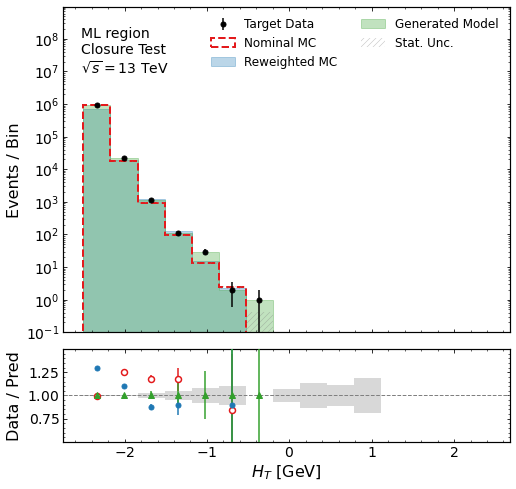

Plotting met_recalc_pt...
  -> Nominal: chi2/ndf=4095.67/14 (p=0.0000) | W1=0.1658
  -> Reweight: chi2/ndf=9302.86/14 (p=0.0000) | W1=0.0824
  -> Gen: chi2/ndf=0.00/14 (p=1.0000) | W1=0.0000


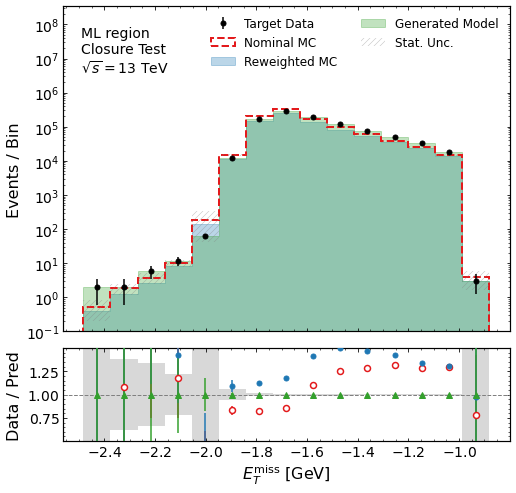

Plotting mjj...
  -> Nominal: chi2/ndf=135.77/11 (p=0.0000) | W1=0.0318
  -> Reweight: chi2/ndf=3275.79/11 (p=0.0000) | W1=0.0492
  -> Gen: chi2/ndf=57.40/8 (p=0.0000) | W1=0.0089


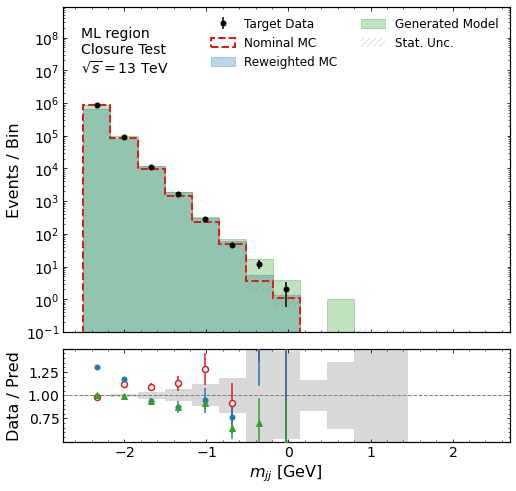

Plotting ljet1_tau21...
  -> Nominal: chi2/ndf=506.67/14 (p=0.0000) | W1=0.0875
  -> Reweight: chi2/ndf=3242.66/14 (p=0.0000) | W1=0.0267
  -> Gen: chi2/ndf=2004.69/14 (p=0.0000) | W1=0.0198


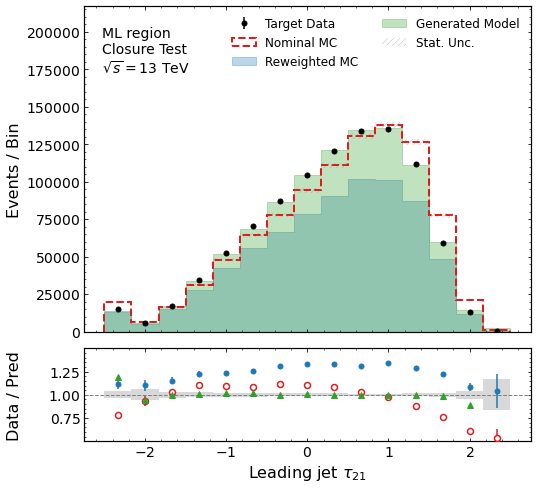

Plotting ljet1_tau32...
  -> Nominal: chi2/ndf=741.65/14 (p=0.0000) | W1=0.0842
  -> Reweight: chi2/ndf=3403.19/14 (p=0.0000) | W1=0.0354
  -> Gen: chi2/ndf=732.86/14 (p=0.0000) | W1=0.0108


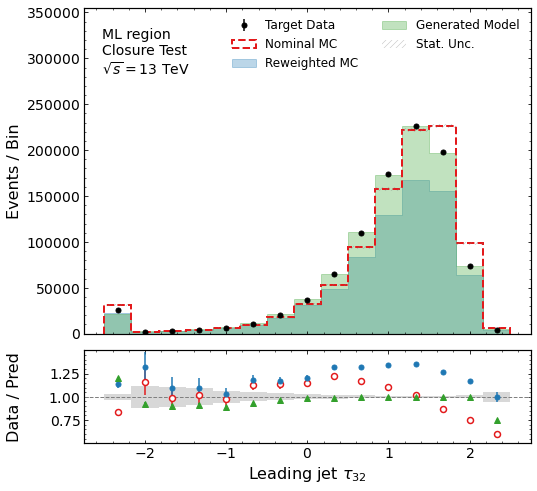

Plotting ljet2_tau21...
  -> Nominal: chi2/ndf=662.27/14 (p=0.0000) | W1=0.1113
  -> Reweight: chi2/ndf=3252.77/14 (p=0.0000) | W1=0.0340
  -> Gen: chi2/ndf=203.64/14 (p=0.0000) | W1=0.0048


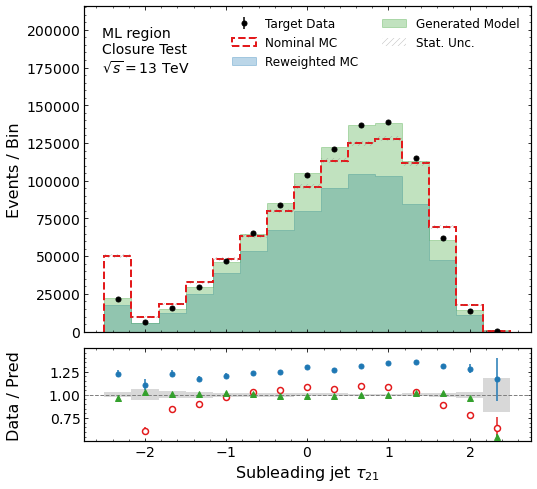

Plotting ljet2_tau32...
  -> Nominal: chi2/ndf=1155.87/14 (p=0.0000) | W1=0.2113
  -> Reweight: chi2/ndf=3241.09/14 (p=0.0000) | W1=0.0095
  -> Gen: chi2/ndf=139.74/14 (p=0.0000) | W1=0.0068


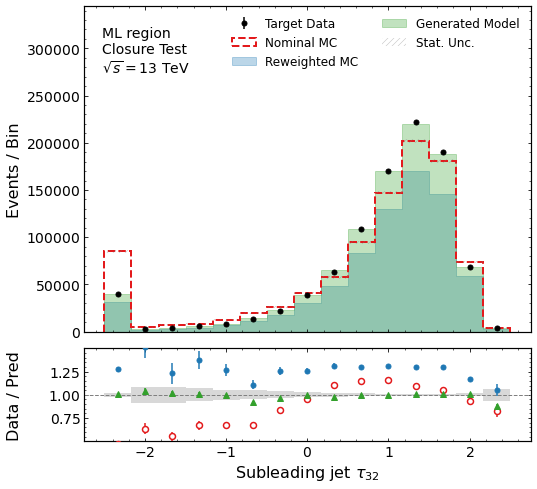

Plotting complete! Check the 'Closure_Plots' directory.
------------------------------------------------------------
Converting to Pandas arrays for CWoLa training...

Data successfully formatted. Ready to execute run_eval()!
  X_mc shape: (635642, 5), w_mc_nom shape: (635642,)
  X_data shape: (960854, 5), w_data shape: (960854,)


In [2]:
# Define the region/selection corresponding to your saved parquet files
selection = "ML" 

print(f"Loading events for {selection}...")
try:
    df_mc = pl.read_parquet(f"AD_Events/CR_events_mc_{selection}.parquet")
    df_data = pl.read_parquet(f"AD_Events/CR_events_data_{selection}.parquet")
    df_gen = pl.read_parquet(f"AD_Events/CR_events_gen_{selection}.parquet")
except Exception as e:
    print(f"Error loading files. Ensure the 'AD_Events' folder exists and files are named correctly.\nError: {e}")
    sys.exit(1)

# Reconstruct the combined reweighted column if it isn't saved in the dataframe
if "reweighted_weight" not in df_mc.columns:
    if "ml_extrapolation_weight" in df_mc.columns and "final_weight" in df_mc.columns:
        df_mc = df_mc.with_columns(
            (pl.col("final_weight") * pl.col("ml_extrapolation_weight")).alias("reweighted_weight")
        )
    else:
        print("Warning: Missing required weight columns in MC file to calculate 'reweighted_weight'.")

# Define Variables
context_var = ['ht', 'met_recalc_pt']
exclude_cols = context_var + ['final_weight', 'ml_extrapolation_weight', 'reweighted_weight', 'raw_weights', 'weight', 'label']
features = [ 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]
all_variables_to_plot = context_var + features

print(f"\nContext Variables: {context_var}")
print(f"Feature Variables: {features}")

# Generate the PDFs
print(f"\nGenerating Pre-CWoLa Closure Plots for {selection}...")
for var in all_variables_to_plot:
    print(f"Plotting {var}...")
    try:
        plot_closure(
            region_name=selection,
            df_mc=df_mc,
            df_gen=df_gen,
            df_data=df_data,
            feature=var,
            force_log=False
        )
    except Exception as e:
        print(f"  Failed to plot {var}: {e}")

print("Plotting complete! Check the 'Closure_Plots' directory.")
print("-" * 60)

# ==============================================================================
# 3. PREPARE DATA FOR CWoLa
# ==============================================================================
print("Converting to Pandas arrays for CWoLa training...")
mc_events_cr = df_mc.to_pandas()
data_events_cr = df_data.to_pandas()
gen_events_cr = df_gen.to_pandas()

# Extract feature arrays (X)
X_mc = mc_events_cr[features].values 
X_gen = gen_events_cr[features].values
X_data = data_events_cr[features].values

# Extract weight arrays (w)
w_mc_nominal = mc_events_cr['final_weight'].values if 'final_weight' in mc_events_cr.columns else np.ones(len(X_mc))
w_mc_reweighted = mc_events_cr['reweighted_weight'].values if 'reweighted_weight' in mc_events_cr.columns else np.ones(len(X_mc))

w_gen = gen_events_cr['weight'].values if 'weight' in gen_events_cr.columns else np.ones(len(X_gen))
w_data = data_events_cr['final_weight'].values if 'final_weight' in data_events_cr.columns else np.ones(len(X_data))

print("\nData successfully formatted. Ready to execute run_eval()!")
print(f"  X_mc shape: {X_mc.shape}, w_mc_nom shape: {w_mc_nominal.shape}")
print(f"  X_data shape: {X_data.shape}, w_data shape: {w_data.shape}")

In [3]:
# def run_eval(set_1, set_2, code, save_dir, classifier_params, device, w_1 = None, w_2 = None, classifier_runs = 20):
    
#     if w_1 is None or w_1.size == 0:
#         w_1 = np.ones(set_1.shape[0])
#     if w_2 is None or w_2.size == 0:
#         w_2 = np.ones(set_2.shape[0])

#     # define test size — roughly 20% or limited to 10,000 samples
#     test_size_ratio = min(10000 / set_1.shape[0], 0.2)

#     # split each dataset independently
#     trainset_1, testset_1, wtrain_1, wtest_1 = train_test_split(
#         set_1, w_1, test_size=test_size_ratio, random_state=42
#     )
#     trainset_2, testset_2, wtrain_2, wtest_2 = train_test_split(
#         set_2, w_2, test_size=test_size_ratio, random_state=42
#     )

#     # ---------- Build train/test sets ----------
#     # Combine the two datasets
#     input_x_train = np.concatenate([trainset_1, trainset_2], axis=0)
#     input_y_train = np.concatenate([
#         np.zeros(trainset_1.shape[0]),
#         np.ones(trainset_2.shape[0])
#     ]).reshape(-1, 1)
#     input_w_train = np.concatenate([wtrain_1, wtrain_2], axis=0).reshape(-1, 1)

#     input_x_test = np.concatenate([testset_1, testset_2], axis=0)
#     input_y_test = np.concatenate([
#         np.zeros(testset_1.shape[0]),
#         np.ones(testset_2.shape[0])
#     ]).reshape(-1, 1)
#     # input_w_test = np.concatenate([wtest_1, wtest_2], axis=0).reshape(-1, 1)
#     n_features = input_x_train.shape[1]
    
#     # ---------- Logging ----------
#     print(f"\nWorking on {code}...")
#     print("      X_train, y_train, w_train:", input_x_train.shape, input_y_train.shape, input_w_train.shape)
#     print("      X_test, y_test:", input_x_test.shape, input_y_test.shape)
    
#     aucs_list = []

#     for i in range(int(classifier_runs)):
        
#         print(f"Classifier run {i+1} of {classifier_runs}.")
#         local_id = f"{code}_run{i}"
                
#         # train classifier
#         NN = Classifier(n_inputs=n_features, layers=classifier_params["layers"], learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
#         print("Using device:", NN.device)
#         NN.train(input_x_train, input_y_train, weights=input_w_train,  save_model=True, model_name = f"model_{local_id}" , n_epochs=classifier_params["n_epochs"], seed = i, outdir=save_dir)

#         scores = NN.evaluation(input_x_test)
#         auc = roc_auc_score(input_y_test, scores, sample_weight=np.concatenate([wtest_1, wtest_2]))
#         if auc < 0.5:
#             auc = 1.0 - auc  # symmetry adjustment
#         aucs_list.append(auc)
#         print(f"   AUC: {auc}")
    
#     # ---------- Save results ----------
#     os.makedirs(f"{save_dir}/auc_scores", exist_ok=True)
#     np.savez(f"{save_dir}/auc_scores/auc_{code}.npz", auc_scores=np.array(aucs_list))

#     print("\nMedian AUC, 16th percentile, 84th percentile:")
#     print(np.median(aucs_list), [np.percentile(aucs_list, 16), np.percentile(aucs_list, 84)])
#     print("Done.\n")

def run_eval(set_1, set_2, code, save_dir, classifier_params, device, w_1=None, w_2=None, classifier_runs=20):
    
    if w_1 is None or w_1.size == 0:
        w_1 = np.ones(set_1.shape[0])
    if w_2 is None or w_2.size == 0:
        w_2 = np.ones(set_2.shape[0])

    n_features = set_1.shape[1]
    
    # ---------- Logging ----------
    print(f"\nWorking on {code}...")
    print(f"      Total Events - Set 1: {set_1.shape[0]}, Set 2: {set_2.shape[0]}")
    
    aucs_list = []

    for i in range(int(classifier_runs)):
        print(f"\nClassifier run {i+1} of {classifier_runs}.")
        local_id = f"{code}_run{i}"
        
        # 2 & 4. SPLIT INSIDE THE LOOP (Flat 20% Test Size)
        # random_state=i ensures a unique train/test combination for each of the 20 runs.
        trainset_1, testset_1, wtrain_1, wtest_1 = train_test_split(
            set_1, w_1, test_size=0.2, random_state=i
        )
        trainset_2, testset_2, wtrain_2, wtest_2 = train_test_split(
            set_2, w_2, test_size=0.2, random_state=i
        )

        # 1. APPLY WEIGHTS AS IS
        # No scaling/normalization applied here to preserve Anomaly Detection physics.
        input_x_train = np.concatenate([trainset_1, trainset_2], axis=0)
        input_y_train = np.concatenate([
            np.zeros(trainset_1.shape[0]),
            np.ones(trainset_2.shape[0])
        ]).reshape(-1, 1)
        
        # Concatenate raw training weights directly
        input_w_train = np.concatenate([wtrain_1, wtrain_2], axis=0).reshape(-1, 1)

        input_x_test = np.concatenate([testset_1, testset_2], axis=0)
        input_y_test = np.concatenate([
            np.zeros(testset_1.shape[0]),
            np.ones(testset_2.shape[0])
        ]).reshape(-1, 1)
        
        # Concatenate raw testing weights directly
        combined_test_weights = np.concatenate([wtest_1, wtest_2])

        if i == 0:
            print(f"      Train shapes: X:{input_x_train.shape}, y:{input_y_train.shape}, w:{input_w_train.shape}")
            print(f"      Test shapes: X:{input_x_test.shape}, y:{input_y_test.shape}")
                
        # 3. NO SCALING APPLIED (scale_data=False)
        NN = Classifier(n_inputs=n_features, layers=classifier_params["layers"], 
                        learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
        
        if i == 0: print("Using device:", NN.device)
        
        NN.train(input_x_train, input_y_train, weights=input_w_train, save_model=True, 
                 model_name=f"model_{local_id}", n_epochs=classifier_params["n_epochs"], seed=i, outdir=save_dir)

        # 4. EVALUATION
        scores = NN.evaluation(input_x_test)
        auc = roc_auc_score(input_y_test, scores, sample_weight=combined_test_weights)
        
        if auc < 0.5:
            auc = 1.0 - auc  # symmetry adjustment
            
        aucs_list.append(auc)
        print(f"   --> AUC: {auc:.4f}")
    
    # ---------- Save results ----------
    os.makedirs(f"{save_dir}/auc_scores", exist_ok=True)
    np.savez(f"{save_dir}/auc_scores/auc_{code}.npz", auc_scores=np.array(aucs_list))

    print("\n--- Summary for", code, "---")
    print(f"Median AUC:       {np.median(aucs_list):.4f}")
    print(f"16th percentile:  {np.percentile(aucs_list, 16):.4f}")
    print(f"84th percentile:  {np.percentile(aucs_list, 84):.4f}")
    print("Done.\n")

In [4]:
device = torch.device("cuda" if False else "cpu")
print("Device:", device)
config_path = "/home/aegis/Titan1/NRAD/data/configs"
eval_dir = f"Eval_CWoLa_CR_{selection}"
os.makedirs(eval_dir, exist_ok=True)
with open(f"{config_path}/bc_discrim.yml", 'r') as stream:
    params = yaml.safe_load(stream)

Device: cpu


In [5]:
print("\nStarting CWoLa: Data vs Nominal MC")
run_eval(X_data, X_mc, code=f"Data_vs_Nom_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_data, w_2=w_mc_nominal)



Starting CWoLa: Data vs Nominal MC

Working on Data_vs_Nom_ML...
      Total Events - Set 1: 960854, Set 2: 635642

Classifier run 1 of 20.
      Train shapes: X:(1277196, 5), y:(1277196, 1), w:(1277196, 1)
      Test shapes: X:(319300, 5), y:(319300, 1)
Using device: cpu


 38%|===>      | 19/50 [22:37<36:54, 71.44s/it]


   --> AUC: 0.5851

Classifier run 2 of 20.


 20%|==        | 10/50 [12:12<48:48, 73.21s/it]  


   --> AUC: 0.5874

Classifier run 3 of 20.


...

   --> AUC: 0.5858

Classifier run 19 of 20.


 40%|====      | 20/50 [15:13<22:49, 45.66s/it]


   --> AUC: 0.5829

Classifier run 20 of 20.


 20%|==        | 10/50 [04:07<16:31, 24.78s/it]


   --> AUC: 0.5868

--- Summary for Data_vs_Nom_ML ---
Median AUC:       0.5836
16th percentile:  0.5792
84th percentile:  0.5874
Done.



In [6]:
print("\nStarting CWoLa: Data vs Reweighted MC")
run_eval(X_data, X_mc, code=f"Data_vs_RW_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_data, w_2=w_mc_reweighted)



Starting CWoLa: Data vs Reweighted MC

Working on Data_vs_RW_ML...
      Total Events - Set 1: 960854, Set 2: 635642

Classifier run 1 of 20.
      Train shapes: X:(1277196, 5), y:(1277196, 1), w:(1277196, 1)
      Test shapes: X:(319300, 5), y:(319300, 1)
Using device: cpu


 26%|==>       | 13/50 [14:50<42:14, 68.49s/it]


   --> AUC: 0.5232

Classifier run 2 of 20.


 34%|===       | 17/50 [20:34<39:56, 72.63s/it]  


   --> AUC: 0.5318

Classifier run 3 of 20.


...

   --> AUC: 0.5267

Classifier run 19 of 20.


 20%|==        | 10/50 [1:04:37<4:18:31, 387.79s/it]


   --> AUC: 0.5195

Classifier run 20 of 20.


 22%|==        | 11/50 [1:10:34<4:10:12, 384.93s/it]


   --> AUC: 0.5265

--- Summary for Data_vs_RW_ML ---
Median AUC:       0.5251
16th percentile:  0.5232
84th percentile:  0.5283
Done.



In [ ]:
print("\nStarting CWoLa: Data vs Generated")
run_eval(X_data, X_gen, code=f"Data_vs_Gen_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_data, w_2=w_gen)


Starting CWoLa: Data vs Generated

Working on Data_vs_Gen_ML...
      Total Events - Set 1: 960854, Set 2: 960854

Classifier run 1 of 20.
      Train shapes: X:(1537366, 5), y:(1537366, 1), w:(1537366, 1)
      Test shapes: X:(384342, 5), y:(384342, 1)
Using device: cpu


 70%|=======   | 35/50 [4:17:28<1:50:20, 441.39s/it]


   --> AUC: 0.5236

Classifier run 2 of 20.


 50%|=====     | 25/50 [2:56:19<2:56:19, 423.20s/it]


   --> AUC: 0.5228

Classifier run 3 of 20.


...

 50%|=====     | 25/50 [2:53:49<2:53:49, 417.19s/it]


   --> AUC: 0.5224

Classifier run 12 of 20.


 46%|====>     | 23/50 [2:44:19<3:12:53, 428.65s/it]


   --> AUC: 0.5235

Classifier run 13 of 20.


 54%|=====     | 27/50 [53:36<20:28, 53.43s/it]   